<a href="https://colab.research.google.com/github/Nireekshithkumar/-OIBSIP/blob/main/DataScience_Task1_IrisFlowerClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np



 Load DataFrame from sklearn

In [59]:
iris=sklearn.datasets.load_iris()

In [60]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [61]:
df["species"] = iris.target


In [62]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [63]:
df.size


750

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [65]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,int64


In [66]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


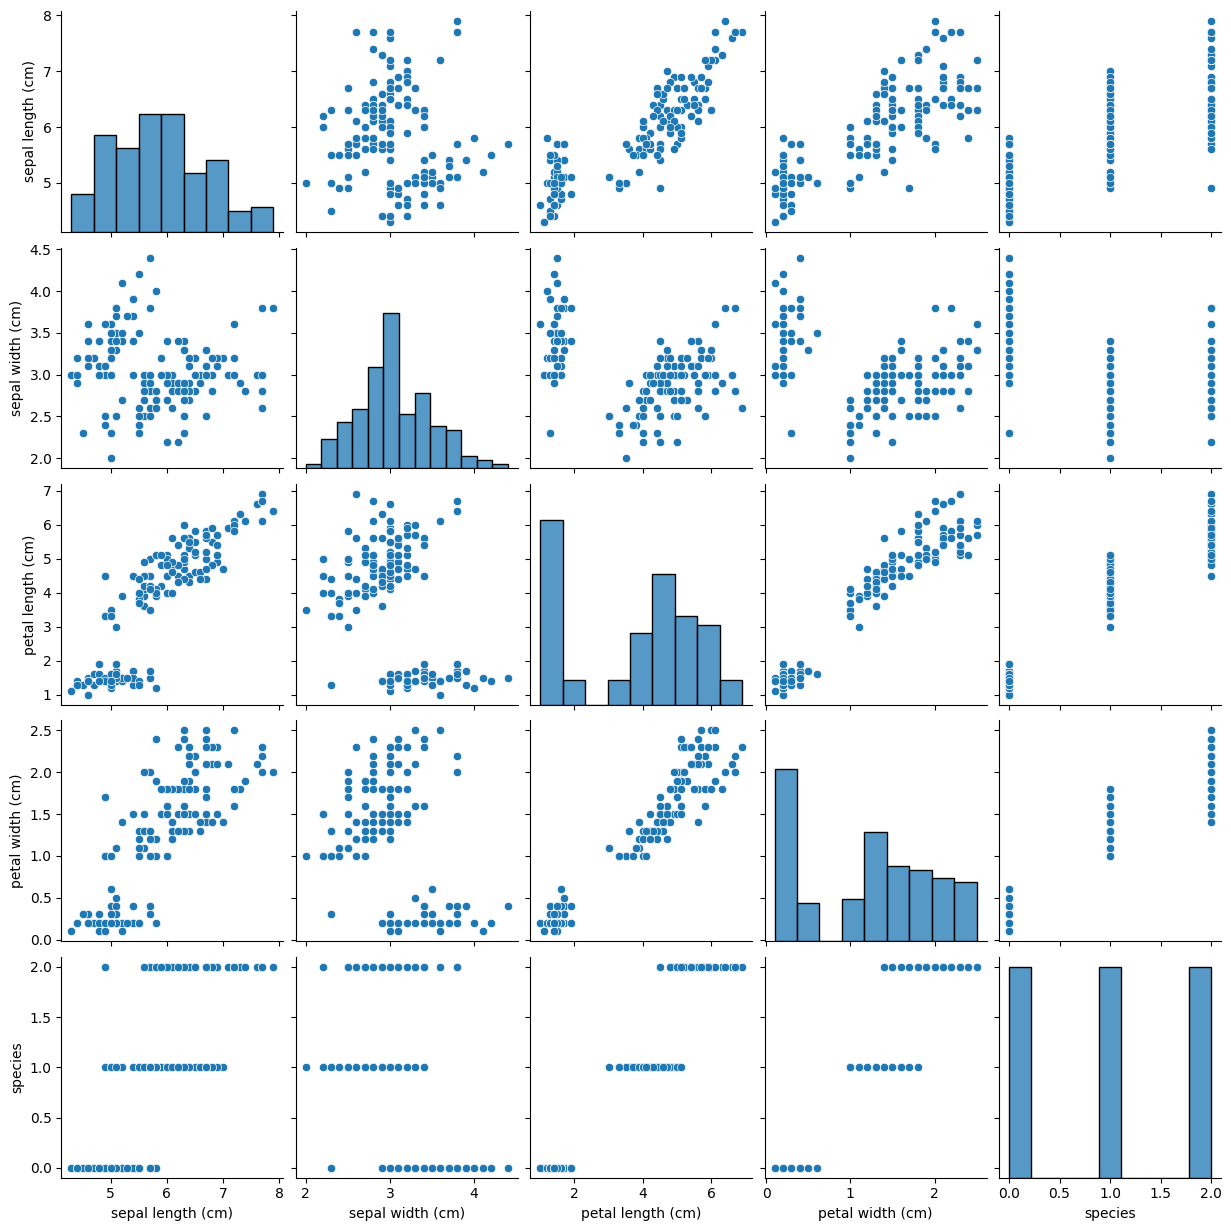

In [67]:
sns.pairplot(df)

<Axes: >

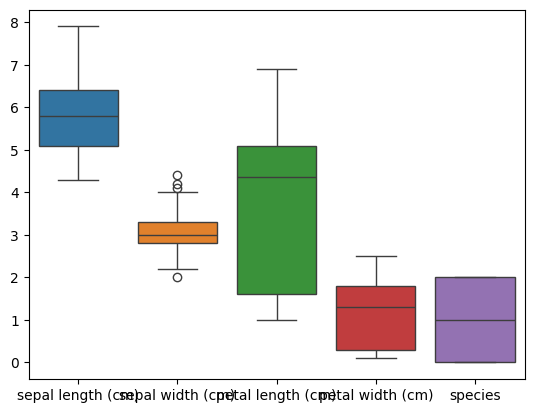

In [68]:
sns.boxplot(df)

In [69]:

def box_plot(df):
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    for i, column in enumerate(df.columns):
        row = i // 2
        col = i % 2
        sns.boxplot(y=df[column], ax=axes[row][col])
        axes[row][col].set_title(column)

IndexError: index 2 is out of bounds for axis 0 with size 2

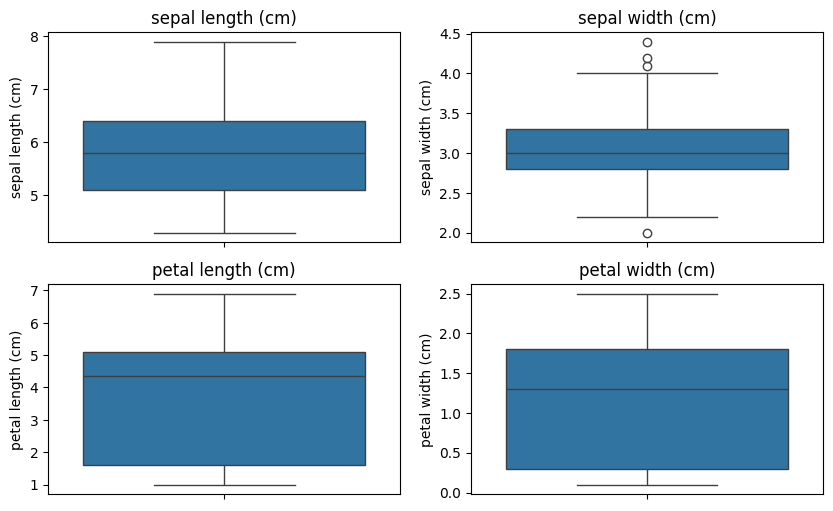

In [70]:
box_plot(df)

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier


In [72]:
df['species'].unique()

array([0, 1, 2])

In [73]:
x=df.drop('species',axis=1)
y=df['species']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [75]:
LogisticModel=LogisticRegression()
LogisticModel.fit(X_train,y_train)

LogisticRegression()

In [97]:
y_pred_LR=LogisticModel.predict(X_test)

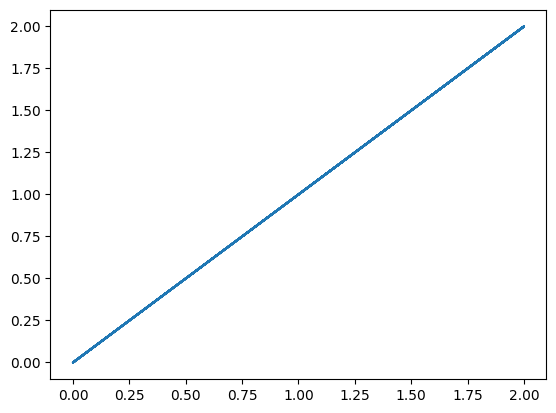

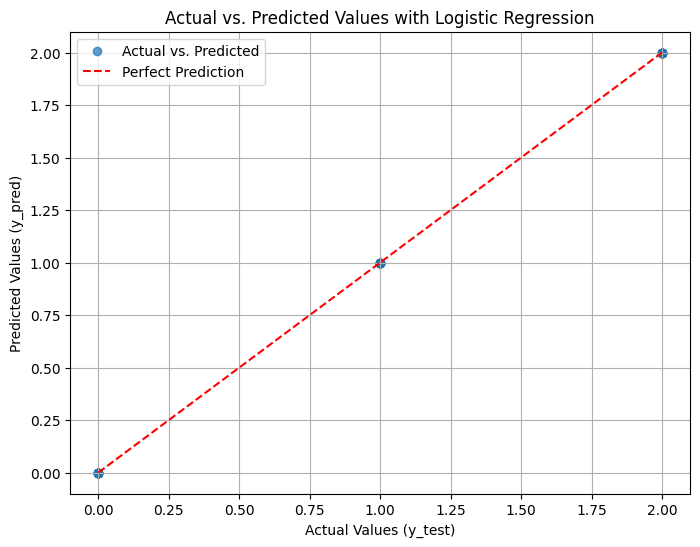

In [98]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_LR, alpha=0.7, label='Actual vs. Predicted')


min_val = min(y_test.min(), y_pred_LR.min())
max_val = max(y_test.max(), y_pred_LR.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values with Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

In [99]:
accuracy_score(y_test,y_pred_LR)

1.0

In [100]:
confusion_matrix(y_test,y_pred_LR)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [101]:
classification_report(y_test,y_pred_LR)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      1.00      1.00         9\n           2       1.00      1.00      1.00        11\n\n    accuracy                           1.00        30\n   macro avg       1.00      1.00      1.00        30\nweighted avg       1.00      1.00      1.00        30\n'

In [93]:
KNN_model=KNeighborsClassifier()
KNN_model.fit(X_train,y_train)

KNeighborsClassifier()

In [102]:
y_pred_KNN=KNN_model.predict(X_test)

In [104]:
accuracy_score(y_test,y_pred_KNN)

1.0

In [105]:
confusion_matrix(y_test,y_pred_KNN)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [106]:
inf_report=classification_report(y_test,y_pred_KNN)
print(inf_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



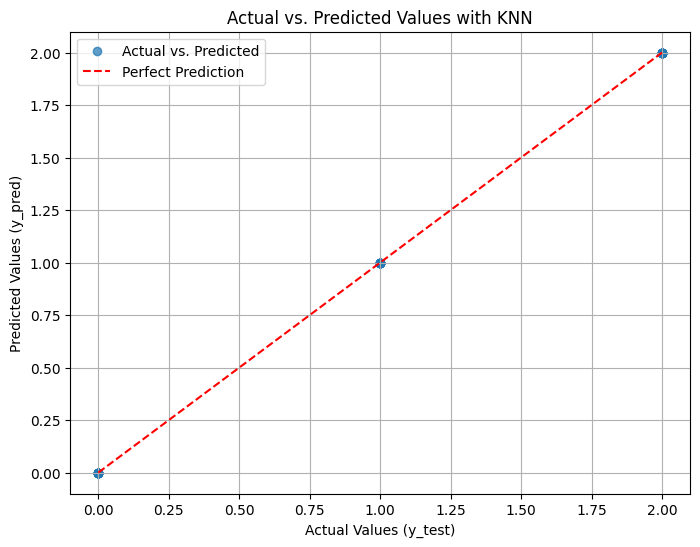

In [103]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_KNN, alpha=0.7, label='Actual vs. Predicted')


min_val = min(y_test.min(), y_pred_KNN.min())
max_val = max(y_test.max(), y_pred_KNN.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values with KNN')
plt.legend()
plt.grid(True)
plt.show()